In [5]:
import pandas as pd
import sys, os
import shap
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)
from src.Fraud.model_training import FraudModelTrainer

In [6]:
df = pd.read_csv("../../data/Fraud/fraud_processed_dataset.csv")


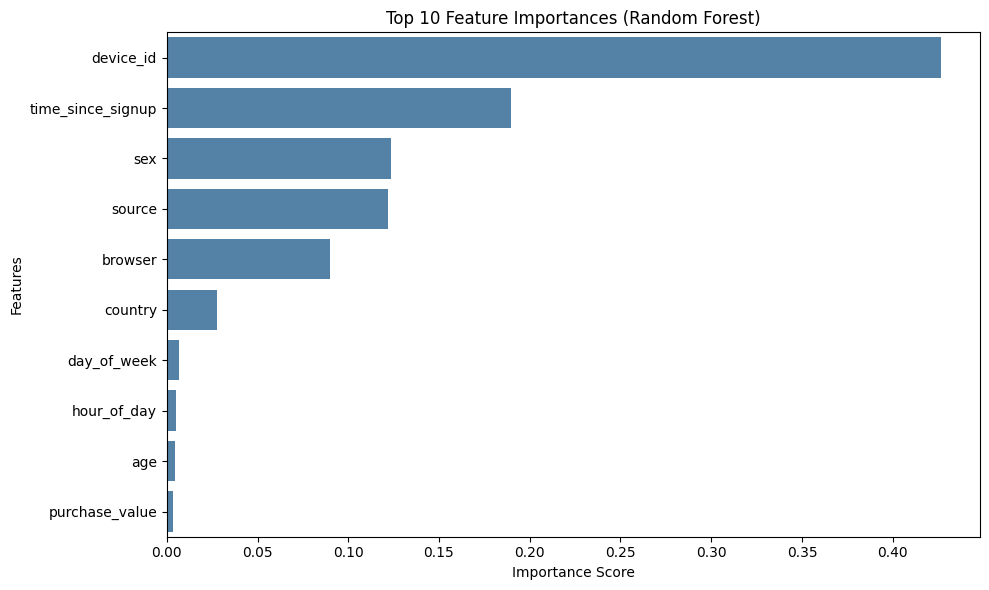

Generating SHAP Summary Plot for Random Forest...


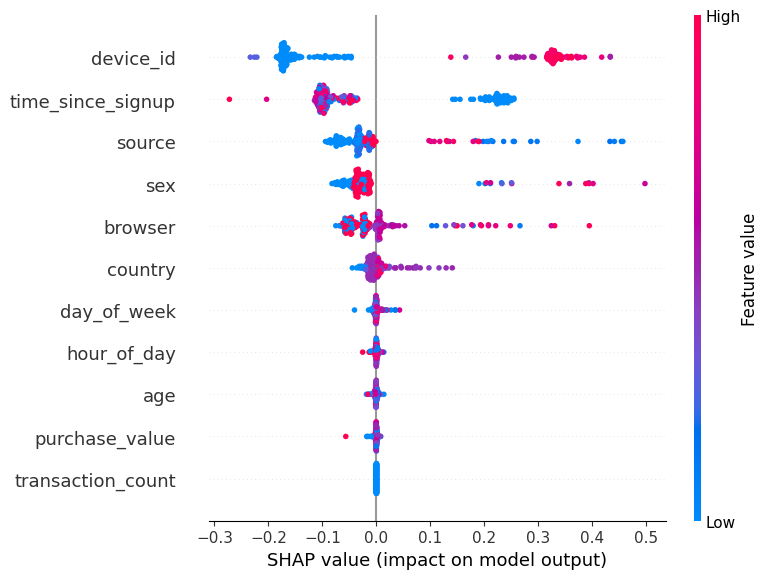

In [7]:
# 1. Initialize
trainer = FraudModelTrainer(
    df=df, 
    target_col="class" 
)

# 2. Prepare (This creates X_train/y_train)
trainer.prepare_data()

# 3. Train (This actually creates the 'Random Forest' model)
trainer.train_random_forest(n_estimators=100)

# --- NOW Task 3 will work ---

# STEP 1: Feature Importance Baseline
trainer.get_feature_importance("Random Forest")

# STEP 2: SHAP Analysis
explainer, shap_vals = trainer.run_shap_analysis("Random Forest", n_samples=200)
# --- STEP 3: Individual Predictions (Local Explainability) ---



--- Case 1: True Positive ---
Plotting True Positive (Correctly Flagged Fraud)...


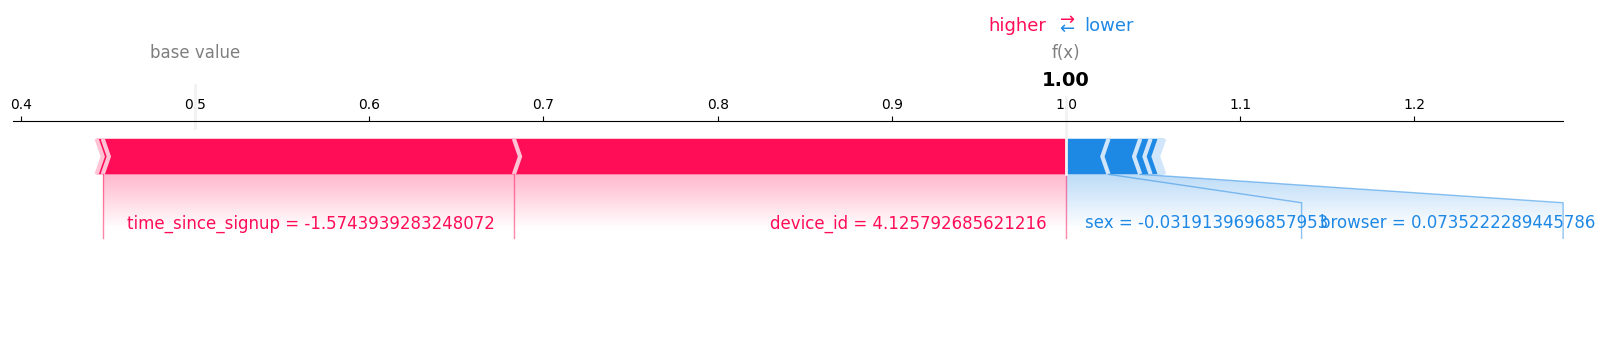


--- Case 2: False Positive ---
Plotting False Positive (Legitimate Flagged as Fraud)...


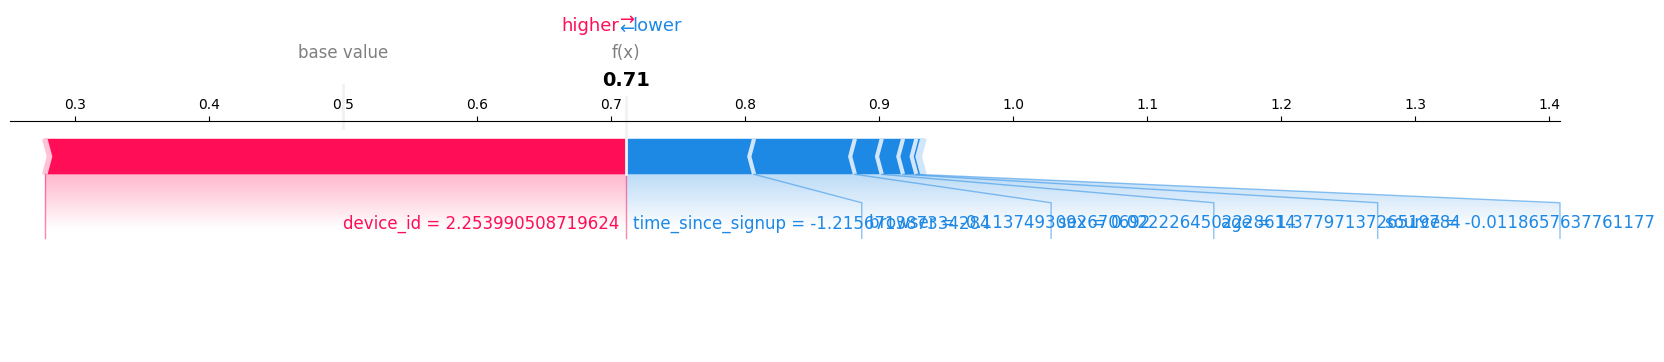


--- Case 3: False Negative ---
Plotting False Negative (Missed Fraud)...


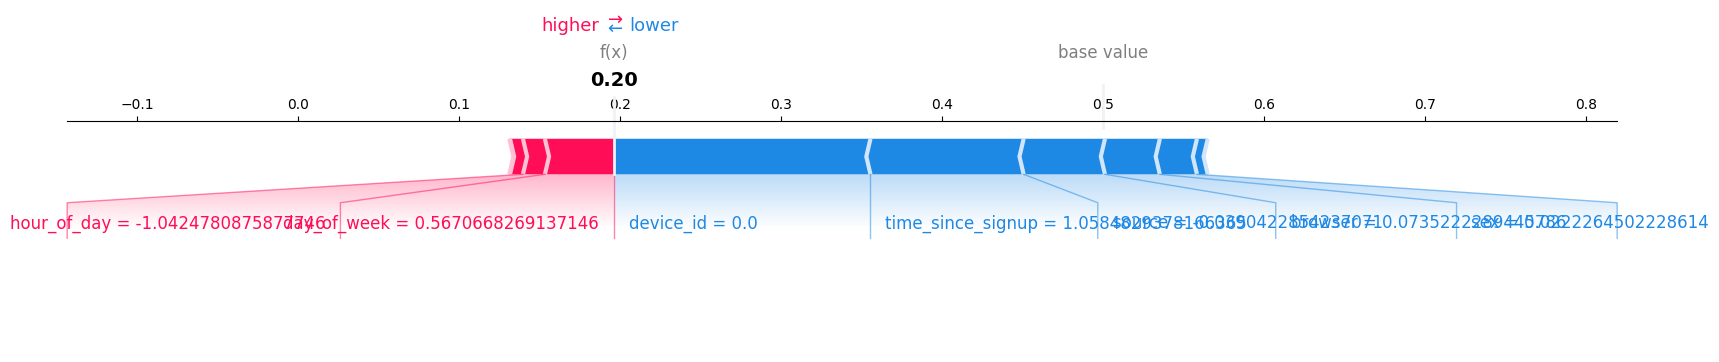

In [8]:
# STEP 2: Initialize the explainer
explainer = shap.TreeExplainer(trainer.models["Random Forest"])

# STEP 3: Individual Predictions (Note: Do NOT pass shap_vals here)
print("--- Case 1: True Positive ---")
trainer.plot_specific_prediction(explainer, case_type="TP")

print("\n--- Case 2: False Positive ---")
trainer.plot_specific_prediction(explainer, case_type="FP")

print("\n--- Case 3: False Negative ---")
trainer.plot_specific_prediction(explainer, case_type="FN")